### portfeliu sudarymas


In [97]:
# pasirenkamos akcijos
akcijos = [
    "ASML.AS",   # ASML Holding
    "SAP.DE",    # SAP
    "SIE.DE",    # Siemens
    "MC.PA",     # LVMH
    "TTE.PA",    # TotalEnergies
    "AIR.PA",    # Airbus
    "SAN.PA",    # Sanofi
    "NESN.SW",   # Nestlé
    "NOVO-B.CO", # Novo Nordisk
    "SAN.MC"     # Banco Santander
]

print(akcijos)

['ASML.AS', 'SAP.DE', 'SIE.DE', 'MC.PA', 'TTE.PA', 'AIR.PA', 'SAN.PA', 'NESN.SW', 'NOVO-B.CO', 'SAN.MC']


In [98]:
akcijos = [
    "NVDA",  # NVIDIA (largest by market cap)
    "AAPL",  # Apple
    "GOOGL", # Alphabet (Google)
    "MSFT",  # Microsoft
    "AMZN",  # Amazon
    "META",  # Meta Platforms
    "AVGO",  # Broadcom
    "TSLA",  # Tesla
    "BRK-B", # Berkshire Hathaway
    "WMT"    # Walmart
]
print(akcijos)

['NVDA', 'AAPL', 'GOOGL', 'MSFT', 'AMZN', 'META', 'AVGO', 'TSLA', 'BRK-B', 'WMT']


In [99]:
import warnings
warnings.filterwarnings("ignore", message="Timestamp\\.utcnow is deprecated")
import yfinance as yf
import pandas as pd

pradzia = "2016-01-01"
pabaiga = "2026-01-01"
duomenys = yf.download(
    akcijos,
    start=pradzia,
    end=pabaiga,
    interval="1d",
    progress=False,
    auto_adjust=True  
)
kainos = duomenys["Close"].copy()
kainos = kainos.dropna(how="all")
kainos = kainos.ffill()
kainos = kainos.dropna()

print("Likusios akcijos:", len(kainos.columns))
print("Akcijų sąrašas:", kainos.columns.tolist())

split_index = int(len(kainos) * 0.8)
train_kainos = kainos.iloc[:split_index]
test_kainos = kainos.iloc[split_index:]
train_returns = train_kainos.pct_change().dropna()
test_returns = test_kainos.pct_change().dropna()

Likusios akcijos: 10
Akcijų sąrašas: ['AAPL', 'AMZN', 'AVGO', 'BRK-B', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']


In [100]:
# skaiciuojamos dienine grazos
train_grazos = train_kainos.pct_change().dropna()
test_grazos = test_kainos.pct_change().dropna()
print("Train grąžų pirmos 5 eilutės:")
print(train_grazos.head())
print("\nTest grąžų pirmos 5 eilutės:")
print(test_grazos.head())
print("\nTrain grąžų dydis:", train_grazos.shape)
print("Test grąžų dydis:", test_grazos.shape)

#metines vidutines grazos ir kovariaciju matrica
mean_returns = train_grazos.mean() * 252
cov_matrix = train_grazos.cov() * 252
print("\nMetinės vidutinės grąžos:")
print(mean_returns)
print("\nKovariacijų matrica:")
print(cov_matrix)

Train grąžų pirmos 5 eilutės:
Ticker          AAPL      AMZN      AVGO     BRK-B     GOOGL      META  \
Date                                                                     
2016-01-05 -0.025059 -0.005024 -0.033455  0.003824  0.002752  0.004989   
2016-01-06 -0.019570 -0.001799 -0.030759  0.000610 -0.002889  0.002336   
2016-01-07 -0.042205 -0.039058 -0.031810 -0.014087 -0.024140 -0.049044   
2016-01-08  0.005288 -0.001464 -0.006587 -0.008882 -0.013617 -0.006025   
2016-01-11  0.016192  0.017610 -0.001248  0.000234  0.002955  0.001849   

Ticker          MSFT      NVDA      TSLA       WMT  
Date                                                
2016-01-05  0.004562  0.016064  0.000090  0.023755  
2016-01-06 -0.018165 -0.041350 -0.019648  0.010013  
2016-01-07 -0.034783 -0.039645 -0.015477  0.023289  
2016-01-08  0.003067 -0.021467 -0.021563 -0.022912  
2016-01-11 -0.000574  0.001688 -0.014929  0.010702  

Test grąžų pirmos 5 eilutės:
Ticker          AAPL      AMZN      AVGO     BRK-B

In [101]:
import numpy as np
from scipy.optimize import minimize

risk_free_rate = 0.02  # gali keisti (pvz. ECB ~2%)
num_assets = len(mean_returns)


def portfolio_performance(weights, mean_returns, cov_matrix):
    port_return = np.sum(weights * mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol


def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    port_return, port_vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(port_return - risk_free_rate) / port_vol

# svoriai 
constraints = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})

bounds = tuple((0, 1) for _ in range(num_assets))
initial_weights = np.ones(num_assets) / num_assets


# Optimizacija
opt_result = minimize(
    negative_sharpe,
    initial_weights,
    args=(mean_returns, cov_matrix, risk_free_rate),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)


optimal_weights = opt_result.x
opt_return, opt_vol = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
opt_sharpe = (opt_return - risk_free_rate) / opt_vol


print("\n=== Maksimalaus Sharpe rodiklio portfelis ===")

weights_df = pd.DataFrame({
    "Akcija": mean_returns.index,
    "Svoris": optimal_weights
})
print("\nOptimalūs svoriai:")
print(weights_df)
print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {opt_return:.4f}")
print(f"Metinė rizika (std): {opt_vol:.4f}")
print(f"Sharpe santykis: {opt_sharpe:.4f}")


=== Maksimalaus Sharpe rodiklio portfelis ===

Optimalūs svoriai:
  Akcija        Svoris
0   AAPL  9.107361e-02
1   AMZN  1.631724e-16
2   AVGO  8.620210e-02
3  BRK-B  0.000000e+00
4  GOOGL  4.347425e-17
5   META  0.000000e+00
6   MSFT  9.145825e-03
7   NVDA  3.772003e-01
8   TSLA  1.163377e-01
9    WMT  3.200405e-01

Portfelio rodikliai:
Metinė grąža: 0.4151
Metinė rizika (std): 0.2909
Sharpe santykis: 1.3584


In [102]:
# bandymas su testiniais duomenimis
test_mean_returns = test_grazos.mean() * 252
test_cov_matrix = test_grazos.cov() * 252
test_return, test_vol = portfolio_performance(
    optimal_weights,
    test_mean_returns,
    test_cov_matrix
)
test_sharpe = (test_return - risk_free_rate) / test_vol
print("\n=== ne imties testas ===")
print(f"Metinė grąža: {test_return:.4f}")
print(f"Metinė rizika: {test_vol:.4f}")
print(f"Sharpe santykis: {test_sharpe:.4f}")


=== ne imties testas ===
Metinė grąža: 0.5732
Metinė rizika: 0.2953
Sharpe santykis: 1.8730


In [103]:
#minimalios dispersijos portfelis
import numpy as np
from scipy.optimize import minimize
num_assets = len(mean_returns)
def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

constraints = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})
bounds = tuple((0, 1) for _ in range(num_assets))  # be short selling
initial_weights = np.ones(num_assets) / num_assets
# Optimizacija
minvar_result = minimize(
    portfolio_volatility,
    initial_weights,
    args=(cov_matrix,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

minvar_weights = minvar_result.x

# treniravimo rodikliai
minvar_return, minvar_vol = portfolio_performance(
    minvar_weights,
    mean_returns,
    cov_matrix
)

minvar_sharpe = (minvar_return - risk_free_rate) / minvar_vol

print("\n=== minimalios dispersijos portfelis treniravimui ===")

weights_df = pd.DataFrame({
    "Akcija": mean_returns.index,
    "Svoris": minvar_weights
})

print("\nOptimalūs svoriai:")
print(weights_df)

print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {minvar_return:.4f}")
print(f"Metinė rizika: {minvar_vol:.4f}")
print(f"Sharpe santykis: {minvar_sharpe:.4f}")


=== minimalios dispersijos portfelis treniravimui ===

Optimalūs svoriai:
  Akcija        Svoris
0   AAPL  5.691390e-18
1   AMZN  5.717944e-02
2   AVGO  5.143377e-18
3  BRK-B  4.784000e-01
4  GOOGL  5.181827e-02
5   META  0.000000e+00
6   MSFT  6.751801e-18
7   NVDA  0.000000e+00
8   TSLA  0.000000e+00
9    WMT  4.126022e-01

Portfelio rodikliai:
Metinė grąža: 0.1616
Metinė rizika: 0.1702
Sharpe santykis: 0.8322


In [104]:
# bandymas su testiniais duomenimis
test_return_mv, test_vol_mv = portfolio_performance(
    minvar_weights,
    test_grazos.mean() * 252,
    test_grazos.cov() * 252
)

test_sharpe_mv = (test_return_mv - risk_free_rate) / test_vol_mv

print("\n=== minimalios dispersijos portfelis testavimui ===")
print(f"Metinė grąža: {test_return_mv:.4f}")
print(f"Metinė rizika: {test_vol_mv:.4f}")
print(f"Sharpe santykis: {test_sharpe_mv:.4f}")


=== minimalios dispersijos portfelis testavimui ===
Metinė grąža: 0.2973
Metinė rizika: 0.1480
Sharpe santykis: 1.8742


In [105]:
#lygiasvoris portfelis

num_assets = len(mean_returns)

equal_weights = np.ones(num_assets) / num_assets

#treniravimo rodikliai
ew_return, ew_vol = portfolio_performance(equal_weights, mean_returns, cov_matrix)
ew_sharpe = (ew_return - risk_free_rate) / ew_vol

print("\n=== lygiasvoris portfelis treniravimui ===")
weights_df = pd.DataFrame({
    "Akcija": mean_returns.index,
    "Svoris": equal_weights
})
print("\nOptimalūs svoriai (lygūs):")
print(weights_df)
print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {ew_return:.4f}")
print(f"Metinė rizika: {ew_vol:.4f}")
print(f"Sharpe santykis: {ew_sharpe:.4f}")

#lygiasvoris portfelis testavimui
test_ew_return, test_ew_vol = portfolio_performance(
    equal_weights,
    test_grazos.mean() * 252,
    test_grazos.cov() * 252
)
test_ew_sharpe = (test_ew_return - risk_free_rate) / test_ew_vol

print("\n=== lygiasvoris portfelis testavimui ===")
print(f"Metinė grąža: {test_ew_return:.4f}")
print(f"Metinė rizika: {test_ew_vol:.4f}")
print(f"Sharpe santykis: {test_ew_sharpe:.4f}")


=== lygiasvoris portfelis treniravimui ===

Optimalūs svoriai (lygūs):
  Akcija  Svoris
0   AAPL     0.1
1   AMZN     0.1
2   AVGO     0.1
3  BRK-B     0.1
4  GOOGL     0.1
5   META     0.1
6   MSFT     0.1
7   NVDA     0.1
8   TSLA     0.1
9    WMT     0.1

Portfelio rodikliai:
Metinė grąža: 0.3113
Metinė rizika: 0.2496
Sharpe santykis: 1.1669

=== lygiasvoris portfelis testavimui ===
Metinė grąža: 0.4084
Metinė rizika: 0.2404
Sharpe santykis: 1.6153


In [ ]:
import matplotlib.pyplot as plt

#simuliacinis portfelis
num_portfolios = 5000

results = np.zeros((3, num_portfolios))
all_weights = []

for i in range(num_portfolios):
    # atsitiktiniai svoriai
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    all_weights.append(weights)
    port_return, port_vol = portfolio_performance(weights, mean_returns, cov_matrix)
    sharpe = (port_return - risk_free_rate) / port_vol
    results[0,i] = port_return
    results[1,i] = port_vol
    results[2,i] = sharpe

# maksimalus sarpo rodiklis iš simuliacijų
max_sharpe_idx = np.argmax(results[2])
ms_return, ms_vol, ms_sharpe = results[:, max_sharpe_idx]
ms_weights = all_weights[max_sharpe_idx]

# minimalios dispersijos portfelis iš simuliacijų
min_vol_idx = np.argmin(results[1])
mv_return, mv_vol, mv_sharpe = results[:, min_vol_idx]
mv_weights = all_weights[min_vol_idx]

# efficinet frontier grafikas
plt.figure(figsize=(10,6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='sarpo rodiklis')
plt.scatter(ms_vol, ms_return, color='r', marker='*', s=200, label='maksimalus sarpo rodiklis')
plt.scatter(mv_vol, mv_return, color='b', marker='*', s=200, label='minimalios dispersijos portfelis')
plt.scatter(ew_vol, ew_return, color='g', marker='*', s=200, label='lygiasvoris portfelis')
plt.title('Efficient Frontier (Monte Carlo Simulation)')
plt.xlabel('Volatility (Std)')
plt.ylabel('Expected Return')
plt.legend()
plt.show()

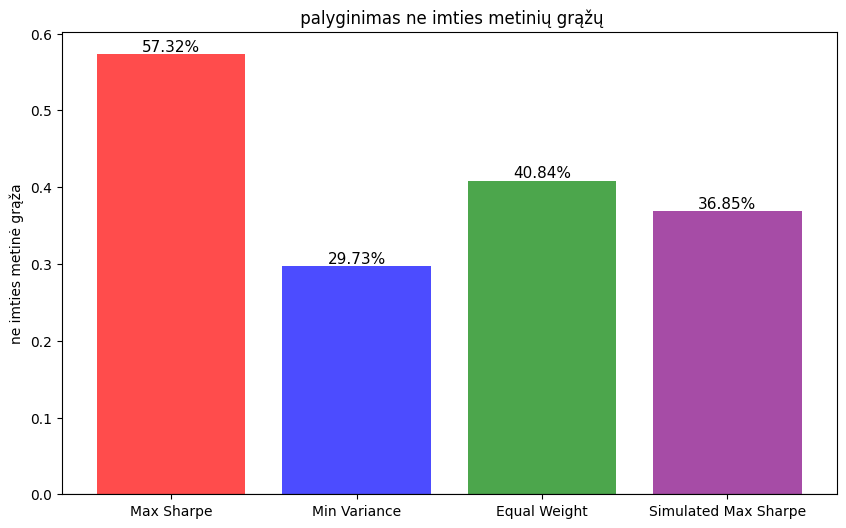

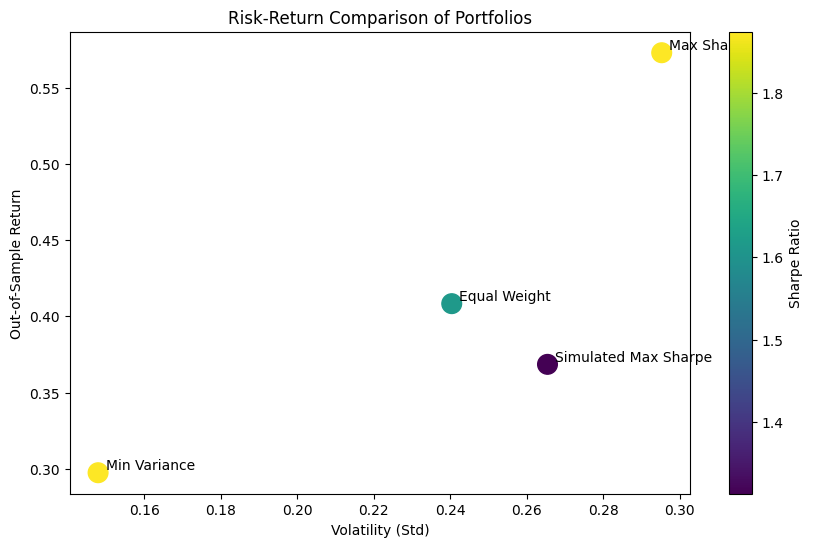

In [ ]:
import matplotlib.pyplot as plt

# testavimas su visais portfeliais
portfolio_names = ['Max Sharpe', 'Min Variance', 'Equal Weight', 'Simulated Max Sharpe']
portfolio_returns = [
    test_return,          # Max Sharpe test
    test_return_mv,       # Min Variance test
    test_ew_return,       # Equal Weight test
    ms_return             # Simulated Max Sharpe (from Monte Carlo)
]

portfolio_vols = [
    test_vol,
    test_vol_mv,
    test_ew_vol,
    ms_vol
]

portfolio_sharpe = [
    test_sharpe,
    test_sharpe_mv,
    test_ew_sharpe,
    ms_sharpe
]

#grazu palyginimas
plt.figure(figsize=(10,6))
bars = plt.bar(portfolio_names, portfolio_returns, color=['red','blue','green','purple'], alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('ne imties metinė grąža')
plt.title(' palyginimas ne imties metinių grąžų')

for bar, ret in zip(bars, portfolio_returns):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{ret:.2%}', ha='center', va='bottom', fontsize=11)

plt.show()

plt.figure(figsize=(10,6))
plt.scatter(portfolio_vols, portfolio_returns, s=200, c=portfolio_sharpe, cmap='viridis')
for i, name in enumerate(portfolio_names):
    plt.text(portfolio_vols[i]+0.002, portfolio_returns[i]+0.002, name)
plt.xlabel('Volatility (Std)')
plt.ylabel('Out-of-Sample Return')
plt.title('Risk-Return Comparison of Portfolios')
plt.colorbar(label='Sharpe Ratio')
plt.show()

In [ ]:
from skfolio.optimization import MaximumDiversification
import pandas as pd


X_train = train_grazos  
maxdiv_model = MaximumDiversification()
maxdiv_model.fit(X_train)
maxdiv_weights = maxdiv_model.weights_
maxdiv_df = pd.DataFrame({
    "Akcija": X_train.columns,
    "Svoris": maxdiv_weights
})
print("\n=== maksimalaus diversifikavimo portfelis train ===")
print(maxdiv_df)


mvdiv_return, mvdiv_vol = portfolio_performance(maxdiv_weights, mean_returns, cov_matrix)
mvdiv_sharpe = (mvdiv_return - risk_free_rate) / mvdiv_vol

print("\nTrain metrics:")
print(f"Return: {mvdiv_return:.4f}, Vol: {mvdiv_vol:.4f}, Sharpe: {mvdiv_sharpe:.4f}")

# bandymas su testiniais duomenimis
test_mean_returns = test_grazos.mean() * 252
test_cov_matrix = test_grazos.cov() * 252

test_mvdiv_return, test_mvdiv_vol = portfolio_performance(maxdiv_weights, test_mean_returns, test_cov_matrix)
test_mvdiv_sharpe = (test_mvdiv_return - risk_free_rate) / test_mvdiv_vol

print("\n=== maksimalaus diversifikavimo portfelis (TEST) ===")
print(f"Test Return: {test_mvdiv_return:.4f}")
print(f"Test Volatility: {test_mvdiv_vol:.4f}")
print(f"Test Sharpe: {test_mvdiv_sharpe:.4f}")


=== maksimalaus diversifikavimo portfelis train ===
  Akcija        Svoris
0   AAPL  4.605583e-07
1   AMZN  5.894461e-02
2   AVGO  5.772114e-02
3  BRK-B  2.020097e-01
4  GOOGL  7.290052e-07
5   META  1.231969e-01
6   MSFT  2.716403e-07
7   NVDA  4.433612e-02
8   TSLA  1.197377e-01
9    WMT  3.940523e-01

Train metrics:
Return: 0.2482, Vol: 0.2032, Sharpe: 1.1233

=== maksimalaus diversifikavimo portfelis (TEST) ===
Test Return: 0.3987
Test Volatility: 0.2002
Test Sharpe: 1.8920


In [ ]:
from skfolio.optimization import RiskBudgeting
from skfolio.measures import RiskMeasure
import pandas as pd

#rizikos pariteto portfelis
risk_parity_model = RiskBudgeting(
    risk_measure=RiskMeasure.VARIANCE,
    portfolio_params=dict(name="Risk Parity - Variance")
)


risk_parity_model.fit(train_grazos)
rp_weights = risk_parity_model.weights_
rp_df = pd.DataFrame({
    "Akcija": train_grazos.columns,
    "Svoris": rp_weights
})

print("\n=== rizikos pariteto portfelis (TRAIN) ===")
print(rp_df)

# treniravimo rodikliai
rp_return, rp_vol = portfolio_performance(rp_weights, mean_returns, cov_matrix)
rp_sharpe = (rp_return - risk_free_rate) / rp_vol

print("\nTrain metrics:")
print(f"Return: {rp_return:.4f}")
print(f"Volatility: {rp_vol:.4f}")
print(f"Sharpe: {rp_sharpe:.4f}")

# bandymas su testiniais duomenimis
test_rp_return, test_rp_vol = portfolio_performance(
    rp_weights,
    test_grazos.mean() * 252,
    test_grazos.cov() * 252
)
test_rp_sharpe = (test_rp_return - risk_free_rate) / test_rp_vol

print("\n=== rizikos pariteto portfelis (TEST) ===")
print(f"Test Return: {test_rp_return:.4f}")
print(f"Test Volatility: {test_rp_vol:.4f}")
print(f"Test Sharpe: {test_rp_sharpe:.4f}")


=== rizikos pariteto portfelis (TRAIN) ===
  Akcija    Svoris
0   AAPL  0.090842
1   AMZN  0.086403
2   AVGO  0.084573
3  BRK-B  0.158860
4  GOOGL  0.093654
5   META  0.078045
6   MSFT  0.091439
7   NVDA  0.058422
8   TSLA  0.062134
9    WMT  0.195627

Train metrics:
Return: 0.2683
Volatility: 0.2175
Sharpe: 1.1414

=== rizikos pariteto portfelis (TEST) ===
Test Return: 0.3775
Test Volatility: 0.2011
Test Sharpe: 1.7775
